## Unsupervised Learning

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)


In [3]:
X

array([[-6.74048189,  4.54387498],
       [ 6.58762596,  5.13973692],
       [-3.52188972,  3.32680266],
       ...,
       [ 9.83885762,  5.33505102],
       [-5.9838192 ,  5.11435029],
       [ 9.60541157,  5.28991652]], shape=(1000, 2))

In [4]:
y

array([0, 2, 1, 0, 1, 2, 0, 2, 0, 1, 1, 0, 1, 2, 1, 2, 2, 0, 0, 1, 0, 1,
       2, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 2, 1, 1, 2, 0, 0, 2, 1, 2, 2, 0,
       2, 1, 1, 0, 0, 2, 1, 0, 0, 0, 0, 0, 2, 1, 2, 0, 2, 1, 1, 0, 1, 2,
       2, 1, 1, 0, 0, 0, 2, 2, 1, 0, 0, 2, 2, 2, 0, 1, 2, 2, 0, 1, 1, 0,
       1, 1, 0, 0, 2, 0, 0, 2, 2, 1, 0, 0, 1, 2, 2, 0, 2, 0, 2, 2, 1, 2,
       1, 1, 0, 2, 1, 1, 2, 1, 1, 0, 0, 2, 1, 0, 0, 1, 1, 1, 0, 2, 2, 0,
       2, 1, 1, 0, 1, 0, 2, 2, 2, 0, 2, 0, 1, 0, 0, 2, 0, 0, 1, 2, 0, 0,
       1, 2, 2, 2, 2, 1, 0, 1, 0, 2, 0, 2, 0, 0, 2, 0, 2, 0, 2, 2, 1, 0,
       2, 1, 0, 2, 1, 1, 1, 0, 1, 2, 1, 1, 2, 0, 1, 0, 0, 2, 0, 0, 0, 2,
       0, 2, 2, 2, 2, 1, 1, 1, 2, 2, 0, 2, 0, 2, 0, 0, 1, 2, 1, 0, 2, 1,
       2, 2, 0, 2, 2, 0, 0, 2, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 2, 0, 0,
       2, 1, 1, 0, 2, 1, 0, 1, 0, 2, 0, 1, 0, 1, 0, 0, 2, 1, 1, 1, 2, 0,
       0, 1, 2, 1, 2, 2, 0, 1, 2, 1, 0, 1, 2, 0, 1, 0, 2, 2, 0, 0, 2, 2,
       2, 0, 0, 2, 0, 0, 2, 0, 0, 0, 1, 1, 2, 2, 1,

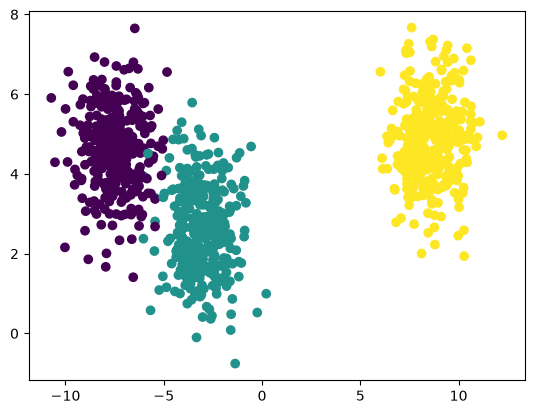

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [8]:
from sklearn.cluster import KMeans
## Elbow method To select K Value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [9]:
wcss

[1339.9999999999995,
 609.8861662235043,
 268.58027716659024,
 210.97596932733106,
 144.4375464500748,
 116.15974906264522,
 104.52567525014268,
 83.4191180206277,
 75.83062153525702,
 61.98312500673734]

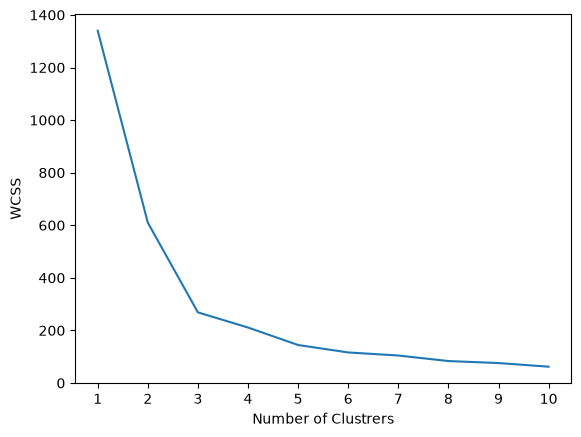

In [10]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [11]:
kmeans=KMeans(n_clusters=3,init="k-means++")
kmeans.fit_predict(X_train_scaled)

array([1, 0, 2, 1, 1, 2, 0, 0, 2, 0, 1, 1, 2, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 2, 1, 2, 1, 0, 0, 2, 0, 0, 0, 1, 2, 2,
       1, 0, 0, 2, 1, 1, 1, 1, 2, 1, 2, 0, 0, 2, 1, 0, 2, 2, 0, 0, 1, 2,
       2, 0, 1, 2, 0, 2, 1, 2, 0, 2, 0, 0, 0, 0, 0, 2, 0, 1, 2, 2, 1, 2,
       0, 0, 1, 1, 2, 2, 0, 1, 2, 1, 1, 2, 2, 1, 2, 0, 0, 0, 0, 0, 0, 1,
       2, 2, 2, 1, 0, 1, 0, 2, 0, 2, 0, 2, 0, 2, 1, 0, 2, 2, 0, 0, 0, 2,
       2, 2, 2, 2, 0, 2, 0, 0, 2, 2, 2, 1, 1, 1, 2, 1, 0, 2, 1, 1, 1, 0,
       2, 1, 2, 2, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 2, 1, 0, 0, 1, 1, 0, 1,
       2, 0, 1, 2, 1, 0, 2, 2, 2, 0, 1, 2, 2, 2, 0, 0, 0, 0, 1, 1, 2, 0,
       2, 1, 1, 0, 2, 2, 2, 1, 1, 1, 2, 2, 2, 0, 1, 0, 0, 0, 1, 0, 2, 0,
       2, 1, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2, 0, 2, 1, 0, 2, 1, 2, 1, 1, 1,
       0, 0, 2, 0, 2, 1, 1, 2, 1, 1, 2, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 2,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 2, 0, 0, 0, 2, 1, 0, 2, 0, 1, 1, 1,
       1, 2, 1, 0, 0, 2, 2, 1, 2, 1, 1, 2, 2, 2, 0,